In [1]:
# Cell 1 - 라이브러리 및 DB 연결

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DB_PATH = r'..\data\db\fintech.db'
conn = sqlite3.connect(DB_PATH)
print("DB 연결 완료")

DB 연결 완료


In [2]:
# Cell 2 - Cohort 기준 정의
# 유저별 첫 거래 연도 (30년치 데이터라서 월 말고 연도로 구분)= Cohort 기준

cohort_base_query = """
SELECT
    User,
    MIN(Year) AS cohort_year
FROM clean_transactions
GROUP BY User
"""

cohort_base = pd.read_sql(cohort_base_query, conn)
print(f"전체 유저 수: {len(cohort_base):,}명")
print(f"Cohort 연도 범위: {cohort_base['cohort_year'].min()} ~ {cohort_base['cohort_year'].max()}")
print(cohort_base['cohort_year'].value_counts().sort_index()) # Cohort별 유저 수 확인

전체 유저 수: 1,657명
Cohort 연도 범위: 1991 ~ 2019
cohort_year
1991      3
1992      2
1993      5
1994      8
1995      7
1996     17
1997     27
1998     38
1999     55
2000     61
2001     97
2002    112
2003    118
2004    138
2005    139
2006    140
2007    139
2008    131
2009     97
2010     89
2011     48
2012     26
2013     22
2014     19
2015     23
2016     15
2017     14
2018     16
2019     51
Name: count, dtype: int64


EDA에서 2003년부터 활성 유저가 본격 증가했다고 확인함. 역시나 **1991~2001년 코호트는 유저 수가 너무 적음(3~97명).**
=> 통계적으로 의미있는 분석을 위해 코호트 최소100명기준으로 잡고 **2002년 이후 코호트만 사용해야될듯**

**WHY?**
**소규모 코호트**를 분석에 포함하면 두가지 문제가 발생함
1. 통계적 노이즈, 3명짜리 코호트에서 1명만 이탈해도 retention이 뚝 떨어짐. 실제 패턴인지 우연인지 구분하기 어려움
2. 히트맵이 지저분해짐, 2003년 이전 코호트까지 히트맵에 넣으면 30개 행이 생겨서 패턴이 보이지 않음. 그래서 **보통 코호트 최소 유저 수 기준(예:50명이상)를 정함** 

In [3]:
# Cell 3 - Cohort Retention Matrix 계산

cohort_retention_query = """
WITH cohort_base AS (
    SELECT
        User,
        MIN(Year) AS cohort_year
    FROM clean_transactions
    WHERE Year >= 2002
    GROUP BY User
),
user_activity AS (
    SELECT DISTINCT
        c.User,
        cb.cohort_year,
        c.Year AS active_year,
        (c.Year - cb.cohort_year) AS years_since_first
    FROM clean_transactions c
    JOIN cohort_base cb ON c.User = cb.User
    WHERE c.Year >= cb.cohort_year
),
cohort_size AS (
    SELECT
        cohort_year,
        COUNT(DISTINCT User) AS cohort_users
    FROM cohort_base
    GROUP BY cohort_year
)
SELECT
    ua.cohort_year,
    ua.years_since_first,
    COUNT(DISTINCT ua.User) AS retained_users,
    cs.cohort_users,
    ROUND(COUNT(DISTINCT ua.User) * 100.0 / cs.cohort_users, 1) AS retention_rate
FROM user_activity ua
JOIN cohort_size cs ON ua.cohort_year = cs.cohort_year
GROUP BY ua.cohort_year, ua.years_since_first
ORDER BY ua.cohort_year, ua.years_since_first
"""

cohort_data = pd.read_sql(cohort_retention_query, conn)
print(f"데이터 shape: {cohort_data.shape}")
print(cohort_data.head(20))

데이터 shape: (171, 5)
    cohort_year  years_since_first  retained_users  cohort_users  \
0          2002                  0             426           426   
1          2002                  1             423           426   
2          2002                  2             421           426   
3          2002                  3             419           426   
4          2002                  4             419           426   
5          2002                  5             421           426   
6          2002                  6             423           426   
7          2002                  7             425           426   
8          2002                  8             424           426   
9          2002                  9             425           426   
10         2002                 10             424           426   
11         2002                 11             425           426   
12         2002                 12             425           426   
13         2002             

실제 2002년 신규 유저는 112명인데 2002년 코호트가 426명으로 잡힘 => 문제있다

In [16]:
# 확인용 쿼리
check_query = """
WITH cohort_base AS (
    SELECT User, MIN(Year) AS cohort_year
    FROM clean_transactions
    WHERE Year >= 2002
    GROUP BY User
)
SELECT cohort_year, COUNT(*) as user_count
FROM cohort_base
GROUP BY cohort_year
ORDER BY cohort_year
"""
print(pd.read_sql(check_query, conn))

    cohort_year  user_count
0          2002         426
1          2003         119
2          2004         139
3          2005         139
4          2006         140
5          2007         141
6          2008         131
7          2009          97
8          2010          89
9          2011          50
10         2012          26
11         2013          22
12         2014          19
13         2015          23
14         2016          15
15         2017          14
16         2018          16
17         2019          51


원인은 WHERE Year >= 2002 조건 때문임

MIN(Year)이 2002년 이상인 유저를 뽑는 건데, 1991~2001년에 첫 거래한 유저들이 2002년 코호트에 몰린 거임

예를 들면 이래요.
유저 A: 실제 첫 거래 1999년 → 2002년 이후 데이터만 보면 MIN(Year)=2002
유저 B: 실제 첫 거래 2002년 → MIN(Year)=2002
둘 다 2002년 코호트로 잡혀버림

=>수정 방법: 전체 transactions에서 첫 거래 연도를 구하고, 그 중 2002년 이후만 필터링해야 해요.

In [17]:
# Cell 3 수정 - Cohort Retention Matrix

cohort_retention_query = """
WITH cohort_base AS (
    -- 전체 데이터에서 진짜 첫 거래 연도
    SELECT
        User,
        MIN(Year) AS cohort_year
    FROM clean_transactions
    GROUP BY User
),
filtered_cohort AS (
    SELECT User, cohort_year
    FROM cohort_base
    WHERE cohort_year >= 2002
),
user_activity AS (
    SELECT DISTINCT
        c.User,
        fc.cohort_year,
        c.Year AS active_year,
        (c.Year - fc.cohort_year) AS years_since_first
    FROM clean_transactions c
    JOIN filtered_cohort fc ON c.User = fc.User
    WHERE c.Year >= fc.cohort_year
),
cohort_size AS (
    SELECT cohort_year, COUNT(DISTINCT User) AS cohort_users
    FROM filtered_cohort
    GROUP BY cohort_year
)
SELECT
    ua.cohort_year,
    ua.years_since_first,
    COUNT(DISTINCT ua.User) AS retained_users,
    cs.cohort_users,
    ROUND(COUNT(DISTINCT ua.User) * 100.0 / cs.cohort_users, 1) AS retention_rate
FROM user_activity ua
JOIN cohort_size cs ON ua.cohort_year = cs.cohort_year
GROUP BY ua.cohort_year, ua.years_since_first
ORDER BY ua.cohort_year, ua.years_since_first
"""

cohort_data = pd.read_sql(cohort_retention_query, conn)

# 2002년 코호트 유저 수 확인
print("코호트별 유저 수 확인:")
print(cohort_data[cohort_data['years_since_first']==0][['cohort_year','cohort_users']])

코호트별 유저 수 확인:
     cohort_year  cohort_users
0           2002           112
18          2003           118
35          2004           138
51          2005           139
66          2006           140
80          2007           139
93          2008           131
105         2009            97
116         2010            89
126         2011            48
135         2012            26
143         2013            22
150         2014            19
156         2015            23
161         2016            15
165         2017            14
168         2018            16
170         2019            51


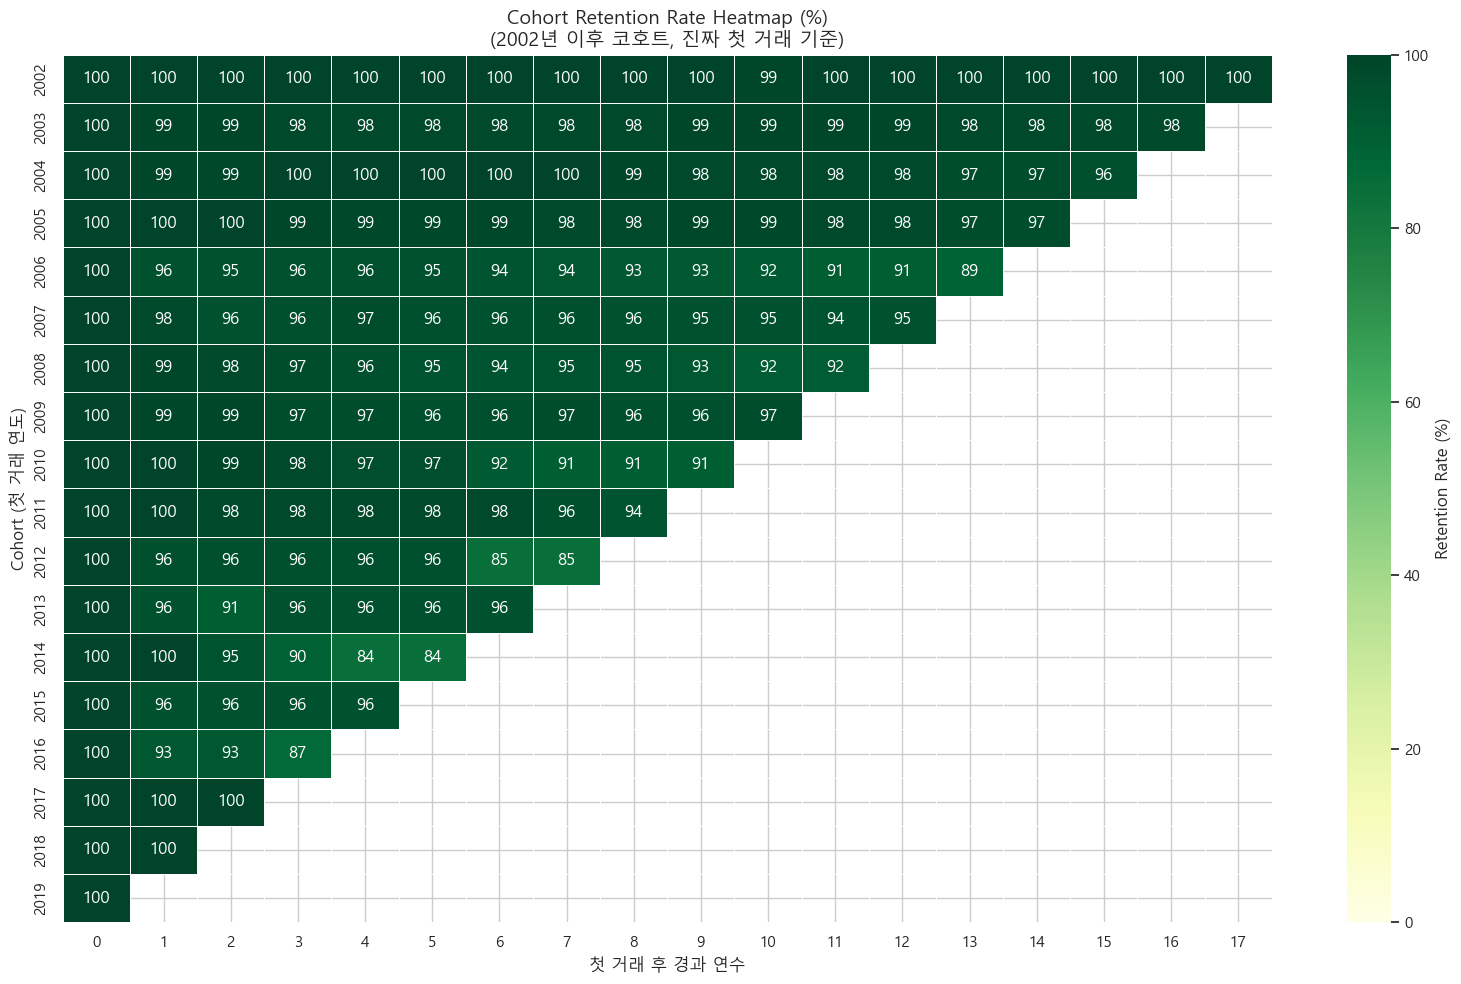

In [18]:
# Cell 4 - Cohort Retention 히트맵

# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

cohort_pivot = cohort_data.pivot_table(
    index='cohort_year',
    columns='years_since_first',
    values='retention_rate'
)

plt.figure(figsize=(16, 10))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'},
    vmin=0,
    vmax=100
)
plt.title('Cohort Retention Rate Heatmap (%)\n(2002년 이후 코호트, 진짜 첫 거래 기준)', fontsize=14)
plt.xlabel('첫 거래 후 경과 연수')
plt.ylabel('Cohort (첫 거래 연도)')
plt.tight_layout()
plt.savefig(r'..\outputs\cohort_retention_heatmap.png', dpi=150)
plt.show()

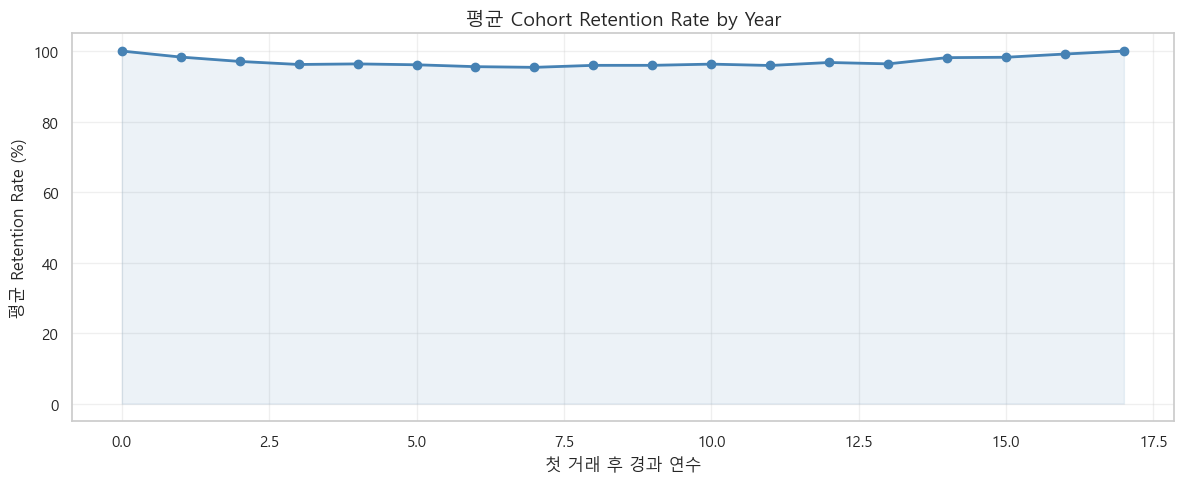


=== 연차별 평균 Retention ===
 years_since_first  retention_rate
                 0      100.000000
                 1       98.288235
                 2       97.050000
                 3       96.186667
                 4       96.350000
                 5       96.100000
                 6       95.566667
                 7       95.372727
                 8       95.940000
                 9       95.944444
                10       96.287500
                11       95.900000
                12       96.750000
                13       96.360000
                14       98.125000
                15       98.233333
                16       99.150000
                17      100.000000


In [21]:
# Cell 5  -코호트 별 retention 추이

avg_retention = cohort_data.groupby('years_since_first')['retention_rate'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(avg_retention['years_since_first'],
         avg_retention['retention_rate'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(avg_retention['years_since_first'],
                 avg_retention['retention_rate'],
                 alpha=0.1, color='steelblue')
plt.title('평균 Cohort Retention Rate by Year', fontsize=14)
plt.xlabel('첫 거래 후 경과 연수')
plt.ylabel('평균 Retention Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'..\outputs\cohort_avg_retention.png', dpi=150)
plt.show()

print("\n=== 연차별 평균 Retention ===")
print(avg_retention.to_string(index=False))

**결과분석**

RETENTION 비율이 너무 높음. 모두 거의 95%~100% 수준임

**WHY ??**
retention정의가 첫 거래연도 이후 특정 연도에 거래가 있는가 이기 때문에 카드 데이터의 특성상 앱서비스와는 달리 카드를 해지하지 않는 이상 매년 한 번씩은 반드시 사용할 거임. 안 쓰는 게 특이한 상황임.

**대안**
1. RETENTION 기준을 수정, 해당 연도에 월 2회 이상 거래 => 실제 활성 유저만으로 데이터 파악가능
2. RETENTION 분석방향 수정, 코호트별 유지율 대신 거래빈도 변화, 거래 금액 변화 등으로 수정 => 시간이 지날수록 더 많이 쓰는가, 덜 쓰는 가 파악 가능 (더 의미있는 인사이트!!)

>코호트별 유지율 대신 거래빈도 변화, 거래 금액 변화 등으로 수정

In [22]:
# Cell 6 - 코호트별 거래 빈도·금액 변화

cohort_behavior_query = """
WITH cohort_base AS (
    SELECT User, MIN(Year) AS cohort_year
    FROM clean_transactions
    GROUP BY User
),
filtered_cohort AS (
    SELECT User, cohort_year
    FROM cohort_base
    WHERE cohort_year >= 2002
),
cohort_size AS (
    SELECT cohort_year, COUNT(DISTINCT User) AS cohort_users
    FROM filtered_cohort
    GROUP BY cohort_year
)
SELECT
    fc.cohort_year,
    (c.Year - fc.cohort_year) AS years_since_first,
    COUNT(*) AS total_tx,
    COUNT(DISTINCT c.User) AS active_users,
    cs.cohort_users,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT c.User), 1) AS avg_tx_per_user,
    ROUND(SUM(CASE WHEN c.Amount > 0 THEN c.Amount ELSE 0 END)
        / COUNT(DISTINCT c.User), 0) AS avg_revenue_per_user
FROM clean_transactions c
JOIN filtered_cohort fc ON c.User = fc.User
JOIN cohort_size cs ON fc.cohort_year = cs.cohort_year
WHERE c.Year >= fc.cohort_year
GROUP BY fc.cohort_year, years_since_first
ORDER BY fc.cohort_year, years_since_first
"""

cohort_behavior = pd.read_sql(cohort_behavior_query, conn)

# 확인
print("2002년 코호트 유저 수:", cohort_behavior[cohort_behavior['cohort_year']==2002]['cohort_users'].values[0])
print(cohort_behavior.head(10))

2002년 코호트 유저 수: 112
   cohort_year  years_since_first  total_tx  active_users  cohort_users  \
0         2002                  0     48895           112           112   
1         2002                  1    111243           112           112   
2         2002                  2    116439           112           112   
3         2002                  3    119307           112           112   
4         2002                  4    123424           112           112   
5         2002                  5    124661           112           112   
6         2002                  6    128307           112           112   
7         2002                  7    129621           112           112   
8         2002                  8    131959           112           112   
9         2002                  9    134907           112           112   

   avg_tx_per_user  avg_revenue_per_user  
0            436.6               22881.0  
1            993.2               51346.0  
2           1039.6       

**결과분석**

0년차가 435회인데 1년차가 993회로 2배이상 많아짐
0년차는 첫 거래시점부터 연말까지로 오전한 1년이 아님
1년차부터 온전한 1년치 데이터라고 할 수 있음
그리고 1년차 이후부터는 꾸준히 사용이 증가하는 패턴이 보임
=> 시간이 지날수록 더 많이 사용함

In [23]:
# 인덱스 생성 (쿼리 속도 개선)
print("인덱스 생성 중...")
conn.execute("CREATE INDEX IF NOT EXISTS idx_user ON transactions(\"User\")")
conn.execute("CREATE INDEX IF NOT EXISTS idx_year ON transactions(\"Year\")")
conn.execute("CREATE INDEX IF NOT EXISTS idx_user_year ON transactions(\"User\", \"Year\")")
conn.commit()
print("인덱스 생성 완료!")

인덱스 생성 중...


OperationalError: database is locked

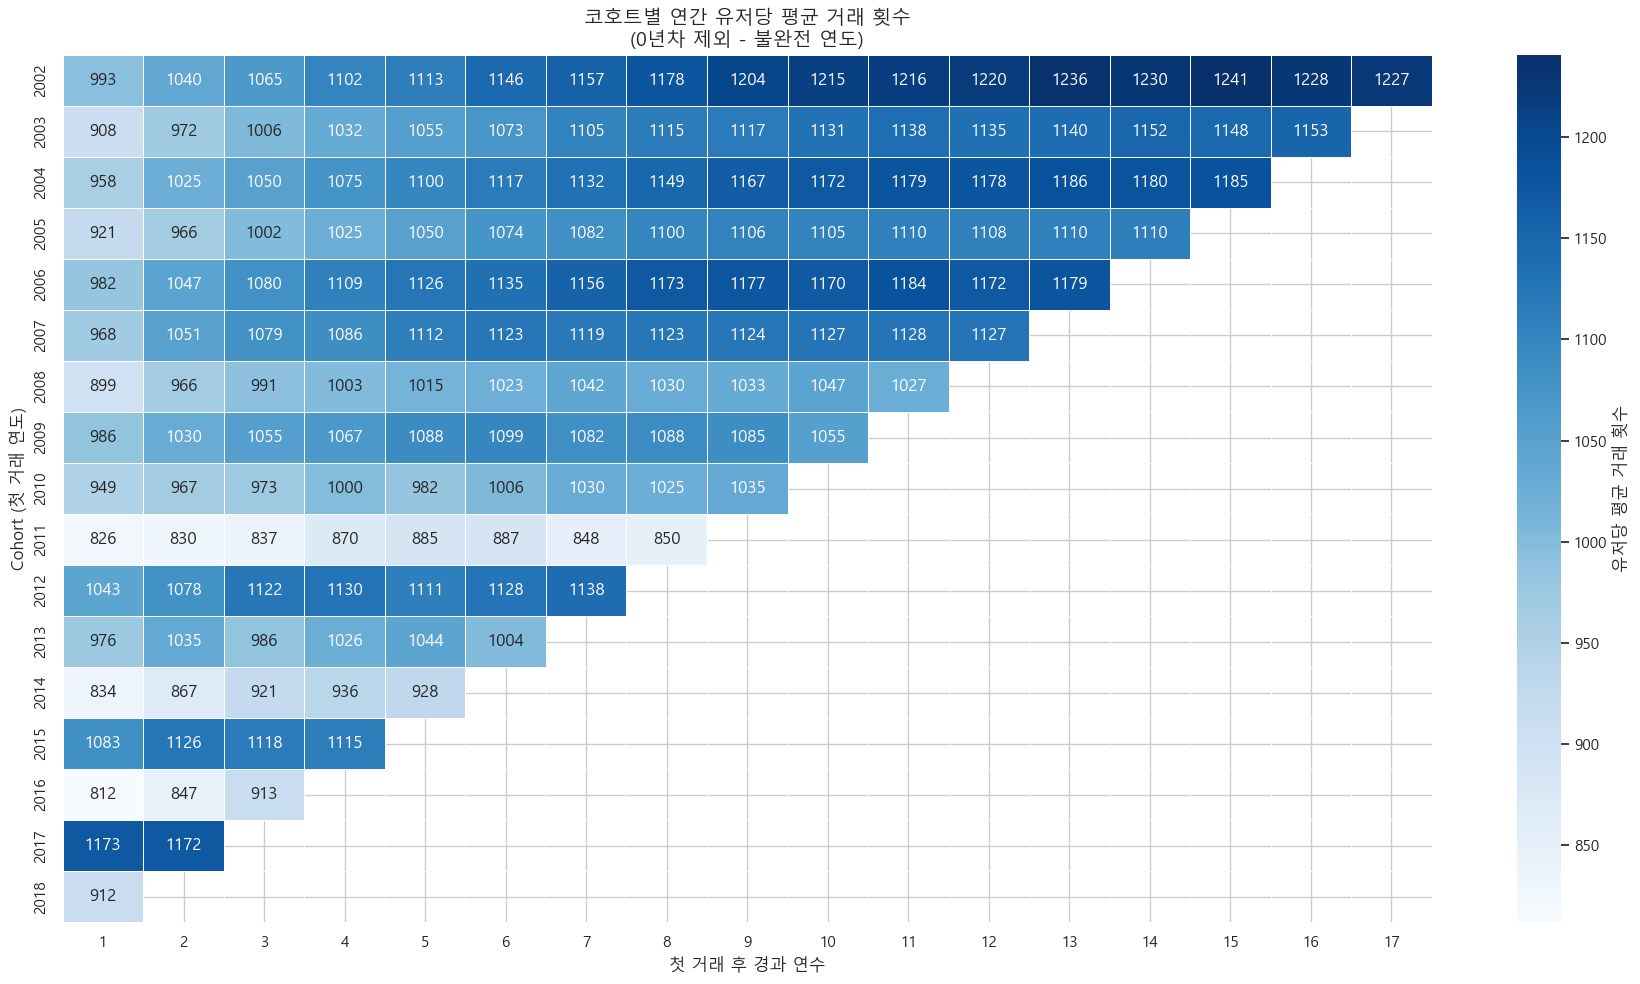

 cohort_year  years_since_first  total_tx  active_users  cohort_users  avg_tx_per_user  avg_revenue_per_user
        2002                  1    111243           112           112            993.2               51346.0
        2002                  2    116439           112           112           1039.6               53873.0
        2002                  3    119307           112           112           1065.2               55196.0
        2002                  4    123424           112           112           1102.0               56330.0
        2002                  5    124661           112           112           1113.0               56376.0
        2002                  6    128307           112           112           1145.6               57166.0
        2002                  7    129621           112           112           1157.3               57490.0
        2002                  8    131959           112           112           1178.2               58005.0
        2002       

In [27]:
# Cell 7 - 거래 빈도 히트맵 (0년차 제외)
# 0년차는 불완전한 연도라 제외

cohort_behavior_filtered = cohort_behavior[cohort_behavior['years_since_first'] > 0]

freq_pivot = cohort_behavior_filtered.pivot_table(
    index='cohort_year',
    columns='years_since_first',
    values='avg_tx_per_user'
)

plt.figure(figsize=(18, 10))
sns.heatmap(
    freq_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': '유저당 평균 거래 횟수'}
)
plt.title('코호트별 연간 유저당 평균 거래 횟수\n(0년차 제외 - 불완전 연도)', fontsize=14)
plt.xlabel('첫 거래 후 경과 연수')
plt.ylabel('Cohort (첫 거래 연도)')
plt.tight_layout()
plt.savefig(r'..\outputs\cohort_tx_frequency.png', dpi=150)
plt.show()
print(cohort_behavior_filtered.to_string(index=False))


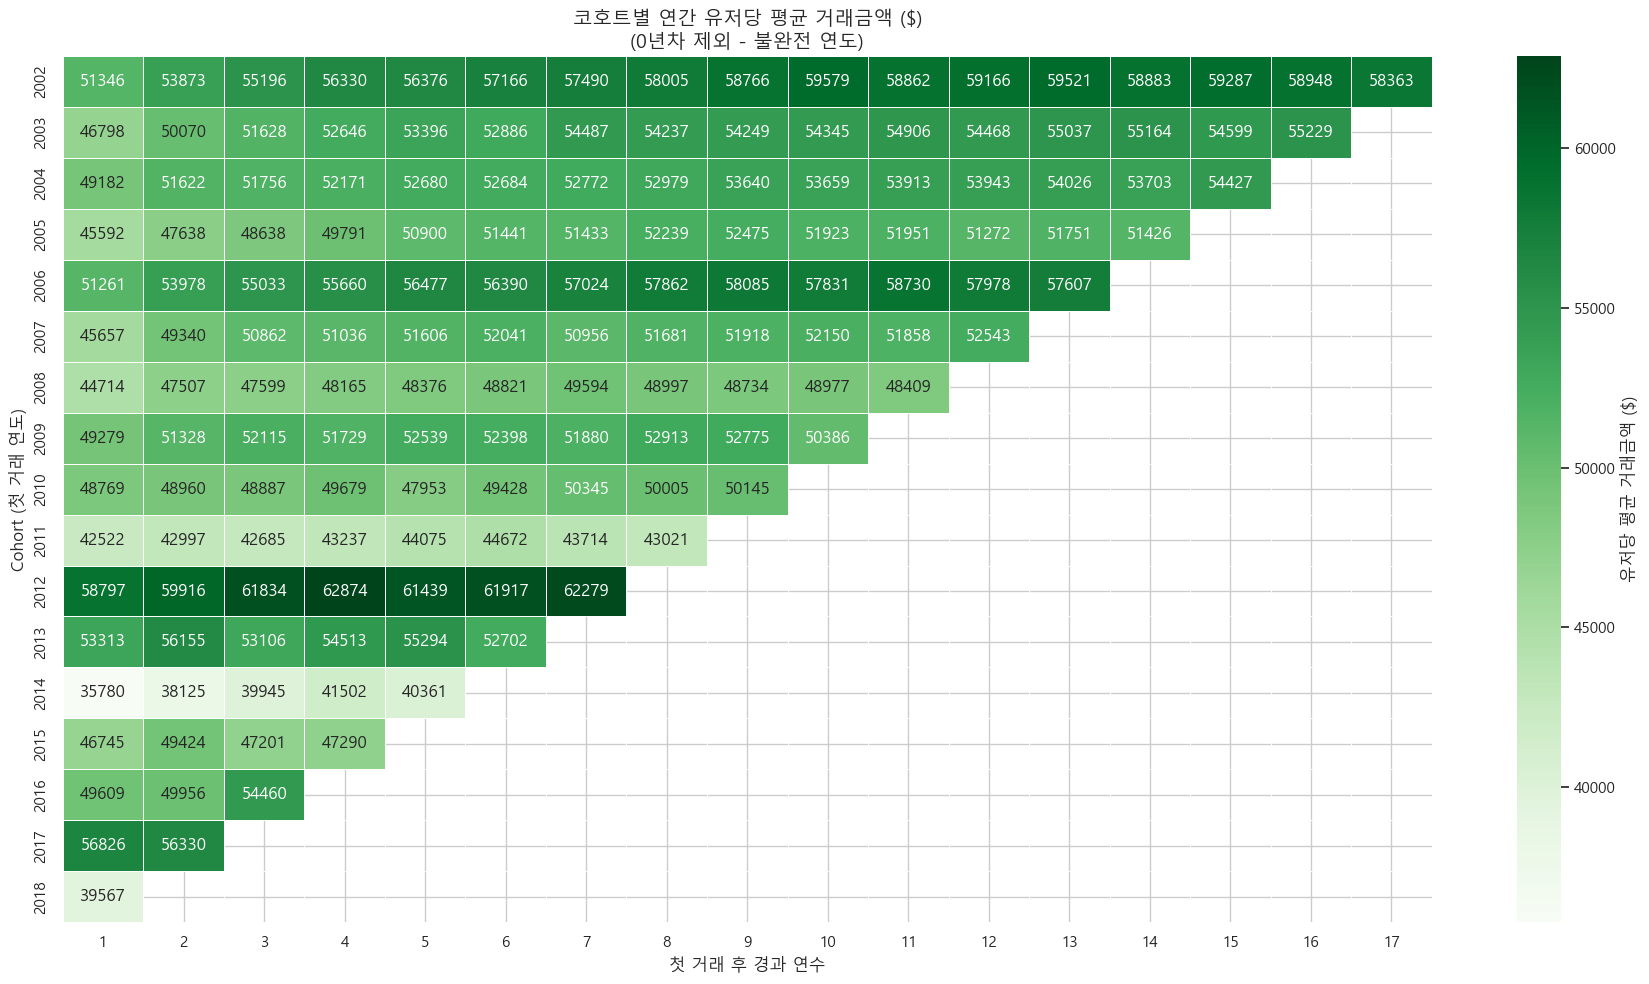

In [31]:
# Cell 8 - 거래금액 히트맵

revenue_pivot = cohort_behavior_filtered.pivot_table(
    index='cohort_year',
    columns='years_since_first',
    values='avg_revenue_per_user'
)

plt.figure(figsize=(18, 10))
sns.heatmap(
    revenue_pivot,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    linewidths=0.5,
    cbar_kws={'label': '유저당 평균 거래금액 ($)'}
)
plt.title('코호트별 연간 유저당 평균 거래금액 ($)\n(0년차 제외 - 불완전 연도)', fontsize=14)
plt.xlabel('첫 거래 후 경과 연수')
plt.ylabel('Cohort (첫 거래 연도)')
plt.tight_layout()
plt.savefig(r'..\outputs\cohort_revenue.png', dpi=150)
plt.show()

In [38]:
# 2011, 2012년 코호트의 행동 변화 확인
print(cohort_behavior_filtered[(cohort_behavior_filtered['cohort_year'] == 2011) 
| (cohort_behavior_filtered['cohort_year'] == 2012) ].to_string(index=False))

 cohort_year  years_since_first  total_tx  active_users  cohort_users  avg_tx_per_user  avg_revenue_per_user
        2011                  1     39664            48            48            826.3               42522.0
        2011                  2     39007            47            48            829.9               42997.0
        2011                  3     39344            47            48            837.1               42685.0
        2011                  4     40911            47            48            870.4               43237.0
        2011                  5     41606            47            48            885.2               44075.0
        2011                  6     41684            47            48            886.9               44672.0
        2011                  7     39007            46            48            848.0               43714.0
        2011                  8     38242            45            48            849.8               43021.0
        2012       

- 2011년: 826~887회, $42,000~44,000 → 유독 낮음
- 2012년: 1,043~1,138회, $58,000~62,000 → 유독 높음

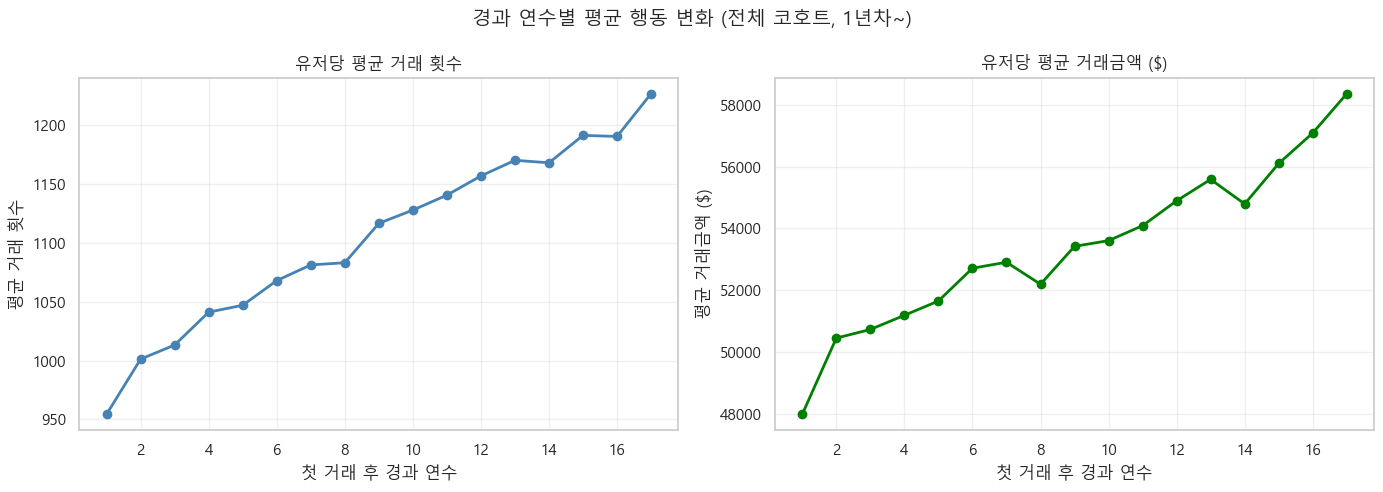


=== 경과 연수별 평균 행동 변화 ===
 years_since_first      avg_tx  avg_revenue
                 1  954.429412 47985.705882
                 2 1001.237500 50451.187500
                 3 1013.200000 50729.666667
                 4 1041.121429 51187.357143
                 5 1046.946154 51651.692308
                 6 1067.908333 52712.166667
                 7 1081.190909 52906.727273
                 8 1083.080000 52193.900000
                 9 1116.511111 53420.777778
                10 1127.762500 53606.250000
                11 1140.457143 54089.857143
                12 1156.766667 54895.000000
                13 1170.040000 55588.400000
                14 1167.925000 54794.000000
                15 1191.200000 56104.333333
                16 1190.300000 57088.500000
                17 1226.600000 58363.000000


In [29]:
# Cell 9 - 전체 평균 추이

avg_trend = cohort_behavior_filtered.groupby('years_since_first').agg(
    avg_tx=('avg_tx_per_user', 'mean'),
    avg_revenue=('avg_revenue_per_user', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('경과 연수별 평균 행동 변화 (전체 코호트, 1년차~)', fontsize=14)

axes[0].plot(avg_trend['years_since_first'], avg_trend['avg_tx'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('유저당 평균 거래 횟수')
axes[0].set_xlabel('첫 거래 후 경과 연수')
axes[0].set_ylabel('평균 거래 횟수')
axes[0].grid(True, alpha=0.3)

axes[1].plot(avg_trend['years_since_first'], avg_trend['avg_revenue'],
             marker='o', color='green', linewidth=2)
axes[1].set_title('유저당 평균 거래금액 ($)')
axes[1].set_xlabel('첫 거래 후 경과 연수')
axes[1].set_ylabel('평균 거래금액 ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'..\outputs\cohort_behavior_trend.png', dpi=150)
plt.show()

print("\n=== 경과 연수별 평균 행동 변화 ===")
print(avg_trend.to_string(index=False))

**핵심 인사이트**

1. 시간이 지날수록 거래 횟수와 금액이 꾸준히 증가함, 1년차 평균 950회 -> 17년차, 1227회로 약 29%증가함. **카드를 오래 쓸수록 더 많이 쓰는 패턴 발견**

2. 거래금액, 거래횟수 히트맵에서 보면 **2002년, 2006년, 2012년, 2017년 코호트**가 전반적으로 진한 녹색임. 이 코호트들이 연간 거래금액이 높은 고가치 코호트를 의미함.

2. **2002년 코호트가 가장 높은 LTV를 보임**, 거래금액 히트맵에서 2002년 행이 전반적으로 가장 진한 녹색임. **초기 유저일수록 충성도가 높음을 발견**

3. **2011 코호트가 유독 낮고, 2012코호트가 유독 높음**, 연속된 연도인데 완전 반대 방향임 -> 2011년은 유저수가 48명, 2012년은 26명으로 적음. **샘플이 작아서 개별 유저특성에 따라 평균이 크게 흔들린것으로 보임**

>=> 2002,2006 처럼 초기의 유저가 높은 충성도를 보임

In [39]:
# 2011, 2012년 코호트 유저 특성 확인
check_query = """
SELECT
    cb.cohort_year,
    COUNT(DISTINCT cb.User) AS user_count,
    ROUND(AVG(u."FICO Score"), 0) AS avg_fico,
    ROUND(AVG(CAST(REPLACE(u."Yearly Income - Person", '$', '') AS FLOAT)), 0) AS avg_income,
    ROUND(AVG(u."Current Age"), 1) AS avg_age
FROM (
    SELECT User, MIN(Year) AS cohort_year
    FROM clean_transactions
    GROUP BY User
) cb
JOIN users u ON cb.User = u.rowid - 1
WHERE cb.cohort_year BETWEEN 2009 AND 2014
GROUP BY cb.cohort_year
ORDER BY cb.cohort_year
"""
print(pd.read_sql(check_query, conn))

   cohort_year  user_count  avg_fico  avg_income  avg_age
0         2009          97     707.0     46854.0     44.2
1         2010          89     708.0     46735.0     42.2
2         2011          48     721.0     43761.0     37.9
3         2012          26     704.0     53352.0     38.9
4         2013          22     711.0     42137.0     38.8
5         2014          19     702.0     39902.0     30.0


FICO, 소득, 나이 다 비슷해서 유저 특성 차이는 님. 그냥 샘플 수가 적어서 생기는 노이즈임

>코호트 규모가 작은 2011년 이후 데이터는 샘플 수 부족으로 변동성이 크므로 해석 시 주의가 필요하다

**예측형 LTV** 

"어느 코호트에 마케팅 투자를 집중해야 하는가?"

: 코호트별 LTV = 연간 평균 거래금액 × 잔존율

이 코호트가 앞으로 얼마나 가치있을 것인가를 예측하는 LTV임

목적: 미래 수익 예측 | 마케팅 투자 결정 

필요 데이터: 거래 이력 + 잔존율

**측정형 LTV**

"현재 어떤 유저가 고가치 유저인가?"

: 유저별 연간 LTV = 총 거래금액 / 활동 연수

이 유저가 지금까지 연평균 얼마나 썼는가를 측정하는 LTV임

목적: 현재 유저 가치 파악 | RFM 세그멘테이션

필요 데이터: 거래 이력


>예측형LTV로 코호트 분석 마무리 | 측정형LTV로 RFM세그멘테이션에 활용 

**예측형LTV**

코호트별 예측 LTV = 연간 평균 거래금액 × 잔존율

잔존율은 %이기 때문에 **잔존연수**를 구해야함.
1. **관찰 기간이 짧을 때 (스타트업, 신규 서비스)** 실제 데이터가 부족하니까 수학적 추정으로 대체함, 유저가 매년 독립적으로 이탈할 확률이 일정하다는 가정하에 기하급수의 합 공식 사용 
평균 잔존 연수 = 1 / (1 - 잔존율) 예: 잔존율 96% => 평균잔존연수 25년 
2. **관찰 기간이 충분할 때**- 실제 데이터를 통해 평균 사용기간을 실제로 측정해서 사용 가능
3. **실무 고급 방법 — BG/NBD 모델**, 토스, 카카오페이 같은 핀테크 기업에서 실제로 쓰는 방법이에요. 유저마다 이탈 확률이 다르다는 걸 고려한 확률 모델 사용, Python lifetimes 라이브러리로 구현 가능
4. **생존 분석 (Survival Analysis)** - 통계학 전공이라 알 수 있는 방법, Kaplan-Meier 추정이나 Cox 비례위험 모델로 유저 이탈 시점을 예측

=> 1번방법, 이탈확률이 매년 일정하지 않음, 초기에 많이 이탈하고 오래된 유저는 이탈율이 더 적음

=> 2번방법 살펴보기

In [46]:
# 실제 관찰된 평균 사용 기간
actual_lifespan_query = """
WITH cohort_base AS (
    SELECT
        User,
        MIN(Year) AS cohort_year,
        MAX(Year) AS last_year,
        (MAX(Year) - MIN(Year)) AS observed_years
    FROM clean_transactions
    GROUP BY User
)
SELECT
    cohort_year,
    COUNT(*) AS user_count,
    ROUND(AVG(observed_years), 1) AS avg_observed_years,
    ROUND(MIN(observed_years), 1) AS min_years,
    ROUND(MAX(observed_years), 1) AS max_years
FROM cohort_base
WHERE cohort_year >= 2002
AND cohort_year <= 2018
GROUP BY cohort_year
ORDER BY cohort_year
"""
print(pd.read_sql(actual_lifespan_query, conn))


    cohort_year  user_count  avg_observed_years  min_years  max_years
0          2002         112                17.0       17.0       17.0
1          2003         118                15.9        5.0       16.0
2          2004         138                14.9        8.0       15.0
3          2005         139                13.8        2.0       14.0
4          2006         140                12.2        0.0       13.0
5          2007         139                11.6        0.0       12.0
6          2008         131                10.5        0.0       11.0
7          2009          97                 9.8        0.0       10.0
8          2010          89                 8.6        2.0        9.0
9          2011          48                 7.8        2.0        8.0
10         2012          26                 6.5        0.0        7.0
11         2013          22                 5.8        1.0        6.0
12         2014          19                 4.5        1.0        5.0
13         2015     

**문제 발견**

2002년 코호트는 avg_observed_years가 17년인데, 이건 데이터가 2019년까지 있어서 잔존연수가 그냥 17년이 된 것임. 반면 2018년 코호트는 1년밖에 안 됐음. 충성도가 낮아서가 아니라 데이터가 1년치밖에 없기 때문임.

=> 최근 코호트일수록 관찰 기간이 짧아서 실제 잔존 기간이 과소 추정되는 문제 발생
이건 어쩔 수 없는 한계. 

=> 뿐만 아니라 이탈시점을 알아야 잔존기간을 알 수 있는데 19년까지 밖에 없기 때문에 유저의 이탈시점을 알 수 없음

=> 예측형 LTV → 데이터 한계로 측정 불가, BG/NBD 모델 등
             실무 방법론 언급으로 대체              

>"예측형 LTV 계산을 시도했으나 데이터 관찰 기간이 코호트별로 다르게 제한되어 있어 편향된 
>
>추정값이 산출됨을 확인했다. 실무에서는 BG/NBD 모델이나 생존 분석(Kaplan-Meier)으로 이탈 
>
>시점을 추정하여 보완할 수 있다."

In [ ]:
# Cell 10 - 기간 보정 연간 LTV 계산

ltv_query = """
WITH cohort_base AS (
    SELECT User, MIN(Year) AS cohort_year, MAX(Year) AS last_year
    FROM clean_transactions
    GROUP BY User
),
filtered_cohort AS (
    SELECT User, cohort_year, last_year
    FROM cohort_base
    WHERE cohort_year >= 2002
),
user_revenue AS (
    SELECT
        c.User,
        SUM(CASE WHEN c.Amount > 0 THEN c.Amount ELSE 0 END) AS total_revenue,
        COUNT(*) AS total_tx
    FROM ltv_transactions c
    JOIN filtered_cohort fc ON c.User = fc.User
    GROUP BY c.User
)
SELECT
    fc.User,
    fc.cohort_year,
    fc.last_year,
    CASE
        WHEN (fc.last_year - fc.cohort_year) = 0 THEN 1 -- 0으로 나누는 경우 방지 
        ELSE (fc.last_year - fc.cohort_year)
    END AS active_years,
    ur.total_revenue,
    ur.total_tx,
    ROUND(ur.total_revenue /
        CASE
            WHEN (fc.last_year - fc.cohort_year) = 0 THEN 1
            ELSE (fc.last_year - fc.cohort_year)
        END, 0) AS annual_ltv, -- 총 거래금액 / 활동 연수 = 연간 평균 거래금액
    ROUND(ur.total_tx /
        CASE
            WHEN (fc.last_year - fc.cohort_year) = 0 THEN 1
            ELSE (fc.last_year - fc.cohort_year)
        END, 0) AS annual_tx -- 총 거래횟수 / 활동 연수 = 연간 평균 거래횟수
FROM filtered_cohort fc
JOIN user_revenue ur ON fc.User = ur.User
"""

ltv_df = pd.read_sql(ltv_query, conn)
print(f"LTV 계산 완료: {len(ltv_df):,}명")
print(ltv_df.describe())

LTV 계산 완료: 1,337명
              User  cohort_year    last_year  active_years  total_revenue  \
count  1337.000000  1337.000000  1337.000000   1337.000000   1.337000e+03   
mean   1001.133134  2007.420344  2018.710546     11.335826   5.978964e+05   
std     570.549092     4.257590     1.497748      4.405887   4.722537e+05   
min       0.000000  2002.000000  2006.000000      1.000000   3.659000e+01   
25%     517.000000  2004.000000  2019.000000      9.000000   2.989784e+05   
50%    1002.000000  2007.000000  2019.000000     12.000000   5.027530e+05   
75%    1478.000000  2009.000000  2019.000000     15.000000   7.716878e+05   
max    1999.000000  2019.000000  2019.000000     17.000000   4.868629e+06   

           total_tx     annual_ltv    annual_tx  
count   1337.000000    1337.000000  1337.000000  
mean   11759.819746   50507.127898   991.123411  
std     7935.206184   33159.748570   533.746157  
min        1.000000      37.000000     1.000000  
25%     6618.000000   30251.000000   6

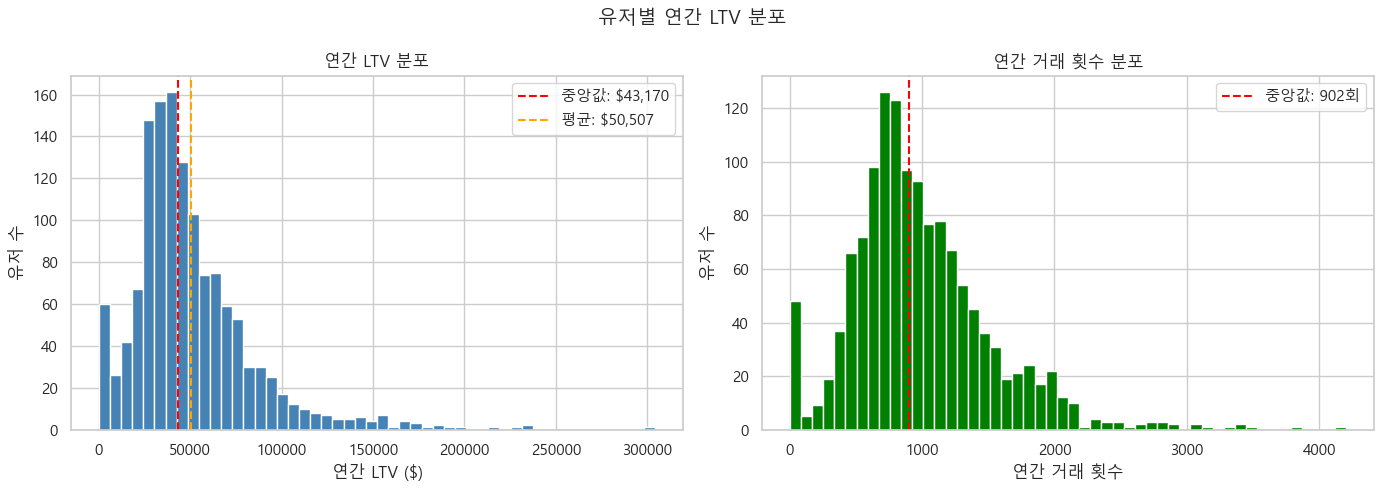


연간 LTV 중앙값: $43,170
연간 LTV 평균: $50,507
연간 LTV 상위 25%: $63,836


In [49]:
# Cell 11 - LTV 분포 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('유저별 연간 LTV 분포', fontsize=14)

axes[0].hist(ltv_df['annual_ltv'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('연간 LTV 분포')
axes[0].set_xlabel('연간 LTV ($)')
axes[0].set_ylabel('유저 수')
axes[0].axvline(ltv_df['annual_ltv'].median(), color='red',
                linestyle='--', label=f"중앙값: ${ltv_df['annual_ltv'].median():,.0f}")
axes[0].axvline(ltv_df['annual_ltv'].mean(), color='orange',
                linestyle='--', label=f"평균: ${ltv_df['annual_ltv'].mean():,.0f}")
axes[0].legend()

axes[1].hist(ltv_df['annual_tx'], bins=50, color='green', edgecolor='white')
axes[1].set_title('연간 거래 횟수 분포')
axes[1].set_xlabel('연간 거래 횟수')
axes[1].set_ylabel('유저 수')
axes[1].axvline(ltv_df['annual_tx'].median(), color='red',
                linestyle='--', label=f"중앙값: {ltv_df['annual_tx'].median():,.0f}회")
axes[1].legend()

plt.tight_layout()
plt.savefig(r'..\outputs\ltv_distribution.png', dpi=150)
plt.show()

print(f"\n연간 LTV 중앙값: ${ltv_df['annual_ltv'].median():,.0f}")
print(f"연간 LTV 평균: ${ltv_df['annual_ltv'].mean():,.0f}")
print(f"연간 LTV 상위 25%: ${ltv_df['annual_ltv'].quantile(0.75):,.0f}")

**인사이트**

- 평균($50,507)이 중앙값($43,170)보다 높음. 오른쪽 꼬리가 긴 분포=> 소수의 고액 사용자가 평균을 끌어올리는 전형적인 금융 데이터 패턴을 보임.

- 연간 거래 횟수도 중앙값 902회인데 오른쪽 꼬리가 김 => 헤비유저가 존재함을 의미함

In [52]:
# Cell 12 - RFM 계산

rfm_query = """
WITH cohort_base AS (
    SELECT User, MIN(Year) AS cohort_year
    FROM clean_transactions
    GROUP BY User
),
filtered_cohort AS (
    SELECT User, cohort_year
    FROM cohort_base
    WHERE cohort_year >= 2002
)
SELECT
    c.User,
    -- Recency: 마지막 거래 연도가 높을수록 최근
    (2019 - MAX(c.Year)) AS recency_years,
    -- Frequency: 연간 평균 거래 횟수
    ROUND(COUNT(*) * 1.0 /
        CASE WHEN (MAX(c.Year) - MIN(c.Year)) = 0 THEN 1
        ELSE (MAX(c.Year) - MIN(c.Year)) END, 0) AS frequency,
    -- Monetary: 연간 평균 거래금액
    ROUND(SUM(CASE WHEN c.Amount > 0 THEN c.Amount ELSE 0 END) /
        CASE WHEN (MAX(c.Year) - MIN(c.Year)) = 0 THEN 1
        ELSE (MAX(c.Year) - MIN(c.Year)) END, 0) AS monetary
FROM clean_transactions c
JOIN filtered_cohort fc ON c.User = fc.User
GROUP BY c.User
"""

rfm_df = pd.read_sql(rfm_query, conn)
print(f"RFM 계산 완료: {len(rfm_df):,}명")
print(rfm_df.describe())

RFM 계산 완료: 1,337명
              User  recency_years    frequency       monetary
count  1337.000000    1337.000000  1337.000000    1337.000000
mean   1001.133134       0.289454  1060.025430   51595.281975
std     570.549092       1.497748   584.565786   34027.463619
min       0.000000       0.000000     1.000000      37.000000
25%     517.000000       0.000000   704.000000   30731.000000
50%    1002.000000       0.000000   960.000000   43848.000000
75%    1478.000000       0.000000  1319.000000   64896.000000
max    1999.000000      13.000000  4983.000000  312306.000000


In [54]:
# Cell 13  - RFM 점수화

# R: recency_years 낮을수록 최근 → 높은 점수
# duplicates='drop' 추가
rfm_df['R'] = pd.qcut(rfm_df['recency_years'],
                       q=5, labels=False,
                       duplicates='drop')
# 0이 가장 최근이므로 점수 반전
rfm_df['R'] = rfm_df['R'].max() - rfm_df['R'] + 1

# F: frequency 높을수록 높은 점수
rfm_df['F'] = pd.qcut(rfm_df['frequency'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)

# M: monetary 높을수록 높은 점수
rfm_df['M'] = pd.qcut(rfm_df['monetary'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)

rfm_df['RFM_score'] = rfm_df['R'] + rfm_df['F'] + rfm_df['M']

print("=== RFM 점수 분포 ===")
print(rfm_df[['User','recency_years','frequency',
              'monetary','R','F','M','RFM_score']].head(10))
print(f"\nRFM 점수 범위: {rfm_df['RFM_score'].min()} ~ {rfm_df['RFM_score'].max()}")
print(f"R 점수 분포:\n{rfm_df['R'].value_counts().sort_index()}")

=== RFM 점수 분포 ===
   User  recency_years  frequency  monetary  R  F  M  RFM_score
0     0              0     1162.0   99616.0  1  4  5         10
1     1              0      550.0   49010.0  1  1  3          5
2     2              0     2441.0   90835.0  1  5  5         11
3     3              0      830.0  105401.0  1  2  5          8
4     5              0     1264.0   75568.0  1  4  5         10
5     6              0     1860.0   71459.0  1  5  5         11
6     8              0     1538.0  108278.0  1  5  5         11
7     9              0     1797.0   66775.0  1  5  4         10
8    13              0      555.0   26874.0  1  1  1          3
9    14              0     1022.0   63850.0  1  3  4          8

RFM 점수 범위: 3 ~ 11
R 점수 분포:
R
1    1337
Name: count, dtype: int64


**문제발생**

R 점수가 전부 1임

recency_years가 대부분 0이라거 분위 나누기가 안됨. 2019년까지 활동한 유저가 거의 대부분이라 recency로 유저를 구분하는 게 의미가 없음 

(데이터특성때문임, 2019년이 데이터 마지막 연도라 대부분 유저의마지막 거래가 2019년임)

**해결 방법** 

1. recency_years=0 → R=5 방식 -  더 많이 씀, Recency의 의미 자체가 "최근에 활동했는가"인데, 2019년까지 활동한 유저는 진짜로 최근 유저가 맞음. 데이터가 2019년에 끝난 게 문제지 유저가 이탈한 게 아니기 때문. 그래서 억지로 다른 지표로 바꾸는 것보다 "0=가장 최근=5점"으로 그대로 쓰는 게 더 직관적임.

2. R 대신 다른 지표로 대체 - 데이터 구조 자체가 Recency를 측정하기 어려울 때 사용함

예를 들어 현 데이터처럼 관찰 기간이 고정되어 있어서 대부분이 같은 값이 나올 때. 근데 이 경우도 사실 "recency_years=0이 너무 많다"는 게 문제지 Recency 자체가 의미없는 건 아님

Recency 대신 거래 빈도 변화율 사용,  "최근 3년 거래 횟수 / 전체 평균 거래 횟수"로 최근 활동성을 측정

>=> 1번 방법 선택, recency_years=0만 R=5로 주는 게 아니라 구간별로 점수를 줌 

In [59]:
# Cell 13 수정 - RFM 점수화

# R: recency_years 구간별 점수 부여
def recency_score(years):
    if years == 0:    return 5  # 2019년까지 활동
    elif years <= 2:  return 4  # 2017~2018년이 마지막
    elif years <= 5:  return 3  # 2014~2016년이 마지막
    elif years <= 9:  return 2  # 2010~2013년이 마지막
    else:             return 1  # 2009년 이전이 마지막

rfm_df['R'] = rfm_df['recency_years'].apply(recency_score)

# F: 연간 평균 거래 횟수 높을수록 높은 점수
rfm_df['F'] = pd.qcut(rfm_df['frequency'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)

# M: 연간 평균 거래금액 높을수록 높은 점수
rfm_df['M'] = pd.qcut(rfm_df['monetary'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)

rfm_df['RFM_score'] = rfm_df['R'] + rfm_df['F'] + rfm_df['M']

print("=== RFM 점수 분포 ===")
print(rfm_df[['User','recency_years','frequency',
              'monetary','R','F','M','RFM_score']].head(10))
print(f"\nRFM 점수 범위: {rfm_df['RFM_score'].min()} ~ {rfm_df['RFM_score'].max()}")
print(f"\nR 점수 분포:\n{rfm_df['R'].value_counts().sort_index()}")

=== RFM 점수 분포 ===
   User  recency_years  frequency  monetary  R  F  M  RFM_score
0     0              0     1162.0   99616.0  5  4  5         14
1     1              0      550.0   49010.0  5  1  3          9
2     2              0     2441.0   90835.0  5  5  5         15
3     3              0      830.0  105401.0  5  2  5         12
4     5              0     1264.0   75568.0  5  4  5         14
5     6              0     1860.0   71459.0  5  5  5         15
6     8              0     1538.0  108278.0  5  5  5         15
7     9              0     1797.0   66775.0  5  5  4         14
8    13              0      555.0   26874.0  5  1  1          7
9    14              0     1022.0   63850.0  5  3  4         12

RFM 점수 범위: 3 ~ 15

R 점수 분포:
R
1      14
2      17
3      21
4      17
5    1268
Name: count, dtype: int64


R=5가 1,268명으로 압도적으로 많음. 대부분 유저가 2019년까지 활동했으니까 당연한 거임

In [63]:
# Cell 14 - RFM 등급 정의

def classify_rfm(row):
    score = row['RFM_score']
    r = row['R']
    f = row['F']
    m = row['M']

    if score >= 13:
        return 'VIP'        # 13~15점: 최근에 자주 많이 씀
    elif score >= 10:
        return 'Loyal'      # 10~12점: 꾸준히 사용
    elif score >= 7:
        return 'Potential'  # 7~9점: 성장 가능성 있음
    # 여기서부터 score 3~6점
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At Risk'    # 점수 낮고 최근 안 씀, 근데 예전엔 잘 썼음
    else:
        return 'Dormant'    # 점수 낮고 최근 안 씀, 원래부터 적게 씀

rfm_df['segment'] = rfm_df.apply(classify_rfm, axis=1)

segment_summary = rfm_df.groupby('segment').agg(
    user_count=('User', 'count'),
    avg_recency=('recency_years', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_rfm_score=('RFM_score', 'mean')
).round(1).sort_values('avg_rfm_score', ascending=False)

print("=== RFM 세그먼트 요약 ===")
print(segment_summary)
print(f"\n전체 유저: {len(rfm_df):,}명")

=== RFM 세그먼트 요약 ===
           user_count  avg_recency  avg_frequency  avg_monetary  avg_rfm_score
segment                                                                       
VIP               421          0.0         1672.4       86667.1           14.1
Loyal             449          0.1          994.3       46426.0           11.1
Potential         434          0.3          584.4       25514.4            8.0
At Risk             2          9.0          636.5       43621.0            6.0
Dormant            31          6.4          380.9       15815.5            4.7

전체 유저: 1,337명


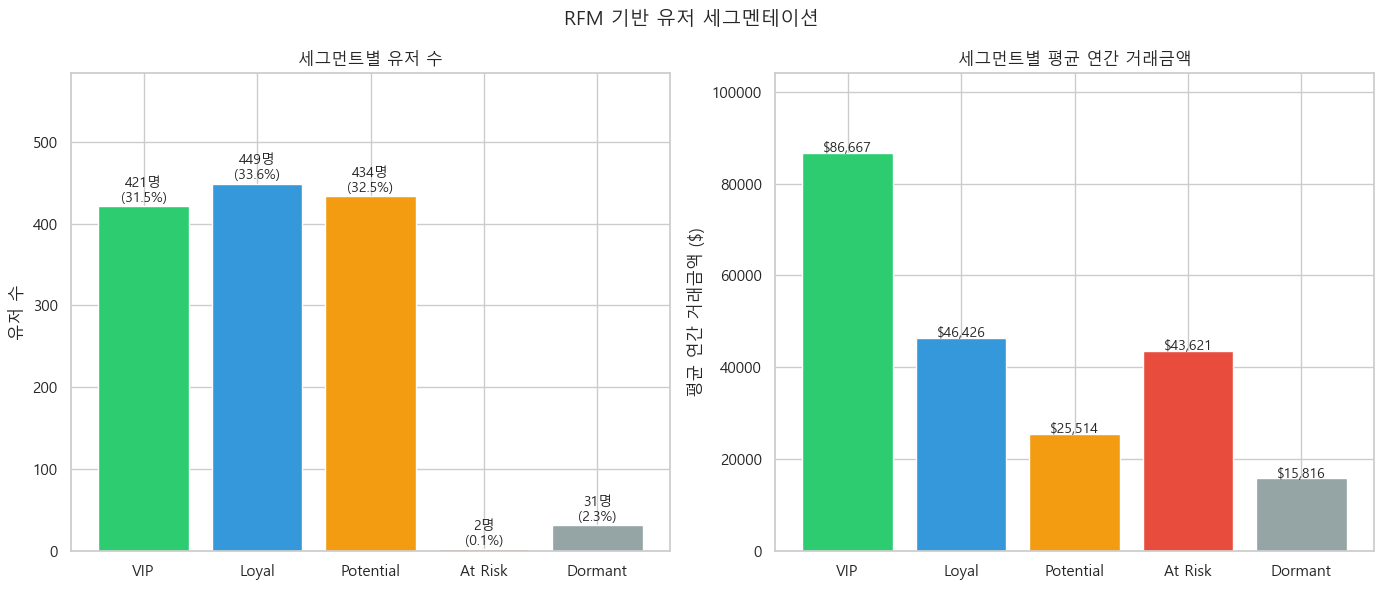

In [64]:
# Cell 15 - RFM 세그먼트 시각화

segment_order = ['VIP', 'Loyal', 'Potential', 'At Risk', 'Dormant']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RFM 기반 유저 세그멘테이션', fontsize=14)

counts = [segment_summary.loc[s, 'user_count']
          if s in segment_summary.index else 0
          for s in segment_order]
ratios = [c/len(rfm_df)*100 for c in counts]

bars = axes[0].bar(segment_order, counts, color=colors)
for bar, count, ratio in zip(bars, counts, ratios):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{count}명\n({ratio:.1f}%)',
                ha='center', fontsize=10)
axes[0].set_title('세그먼트별 유저 수')
axes[0].set_ylabel('유저 수')
axes[0].set_ylim(0, max(counts) * 1.3)

monetary_vals = [segment_summary.loc[s, 'avg_monetary']
                 if s in segment_summary.index else 0
                 for s in segment_order]
bars2 = axes[1].bar(segment_order, monetary_vals, color=colors)
for bar, val in zip(bars2, monetary_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100,
                f'${val:,.0f}',
                ha='center', fontsize=10)
axes[1].set_title('세그먼트별 평균 연간 거래금액')
axes[1].set_ylabel('평균 연간 거래금액 ($)')
axes[1].set_ylim(0, max(monetary_vals) * 1.2)

plt.tight_layout()
plt.savefig(r'..\outputs\rfm_segmentation.png', dpi=150)
plt.show()

**RFM 세그먼트 결과**

- VIP(31.5%), Loyal(33.6%), Potential(32.5%)이 전체의 97.6%를 차지함. At Risk(0.1%)와 Dormant(2.3%)가 매우 적음.

-> 이것도 카드 데이터 특성임. 대부분 유저가 2019년까지 활동해서 R=5를 받았기 때문에 At Risk/Dormant가 적을 수밖에 없음.

**의미있는 인사이트**
- VIP vs Potential 거래금액 차이가 큼. VIP $86,667 vs Potential $25,514로 3.4배 차이. 

-> Potential 유저를 Loyal/VIP로 끌어올리면 수익이 크게 늘 수 있음.
- At Risk 유저 2명은 평균 거래금액이 $43,621로 꽤 높은데 최근 안 쓰고 있음.이탈 방지가 중요한 유저들임


*세그먼트별 행동 비교*

1. VIP는 어떤 카테고리를 많이 쓰는가
2. VIP는 Potential이랑 뭐가 다른가

In [70]:
# Cell 16 - 세그먼트별 행동 비교

# rfm_df에 segment 붙여서 transactions와 조인
segment_behavior_query = """
WITH cohort_base AS (
    SELECT User, MIN(Year) AS cohort_year
    FROM clean_transactions
    GROUP BY User
),
filtered_cohort AS (
    SELECT User, cohort_year
    FROM cohort_base
    WHERE cohort_year >= 2002
)
SELECT
    c.User,
    c.MCC,
    c.Amount,
    c.use_chip,
    c.Year,
    c.Month
FROM clean_transactions c
JOIN filtered_cohort fc ON c.User = fc.User
WHERE c.Amount > 0
"""

behavior_df = pd.read_sql(segment_behavior_query, conn)

# rfm_df의 segment 붙이기
behavior_df = behavior_df.merge(
    rfm_df[['User', 'segment']], on='User', how='left'
)
print(f"행동 데이터: {len(behavior_df):,}행")
display(behavior_df['segment'].value_counts())

행동 데이터: 15,978,322행


segment
VIP          8061530
Loyal        5038269
Potential    2805355
Dormant        70531
At Risk         2637
Name: count, dtype: int64

In [72]:
# Cell 17 - 세그먼트별 거래 패턴 비교

# MCC 대분류 매핑
mcc_category = {
    5411: '식품/식료품', 5499: '식품/식료품', 5300: '식품/식료품',
    5310: '식품/식료품', 5814: '식품/식료품',
    5812: '음식점', 5813: '음식점', 5441: '음식점', 5462: '음식점',
    5541: '교통/자동차', 4121: '교통/자동차', 7538: '교통/자동차',
    4111: '교통/자동차', 4784: '교통/자동차',
    5912: '의료/약국', 5047: '의료/약국', 5122: '의료/약국',
    4829: '금융서비스', 4900: '공과금', 4814: '통신',
    5311: '쇼핑', 5651: '쇼핑', 5661: '쇼핑', 5691: '쇼핑',
    5732: '쇼핑', 5712: '쇼핑', 5999: '쇼핑', 5211: '쇼핑',
    5942: '엔터테인먼트', 7832: '엔터테인먼트', 5945: '엔터테인먼트',
    7011: '여행/숙박', 5921: '편의점', 5813: '주류'
}

behavior_df['category'] = behavior_df['MCC'].map(mcc_category).fillna('기타')

# 세그먼트별 카테고리 비중
seg_category = behavior_df.groupby(['segment', 'category']).agg(
    tx_count=('Amount', 'count'),
    total_amount=('Amount', 'sum')
).reset_index()

# 세그먼트별 비중으로 변환
seg_total = seg_category.groupby('segment')['tx_count'].sum().reset_index()
seg_total.columns = ['segment', 'seg_total']
seg_category = seg_category.merge(seg_total, on='segment')
seg_category['ratio'] = (seg_category['tx_count'] / seg_category['seg_total'] * 100).round(1)

# VIP vs Potential 비교
compare = seg_category[seg_category['segment'].isin(['VIP', 'Potential', 'Loyal'])]
compare_pivot = compare.pivot_table(
    index='category',
    columns='segment',
    values='ratio',
    fill_value=0
).round(1)

print("=== 세그먼트별 카테고리 비중 (%) ===")
display(compare_pivot.sort_values('VIP', ascending=False))

=== 세그먼트별 카테고리 비중 (%) ===


segment,Loyal,Potential,VIP
category,,,
식품/식료품,34.3,32.4,31.4
교통/자동차,17.8,17.0,27.8
기타,11.9,13.8,8.7
음식점,8.0,7.1,7.7
의료/약국,6.6,6.5,5.9
쇼핑,6.3,6.7,5.6
금융서비스,4.4,3.8,5.2
엔터테인먼트,3.3,3.4,2.5
주류,1.8,2.1,1.7


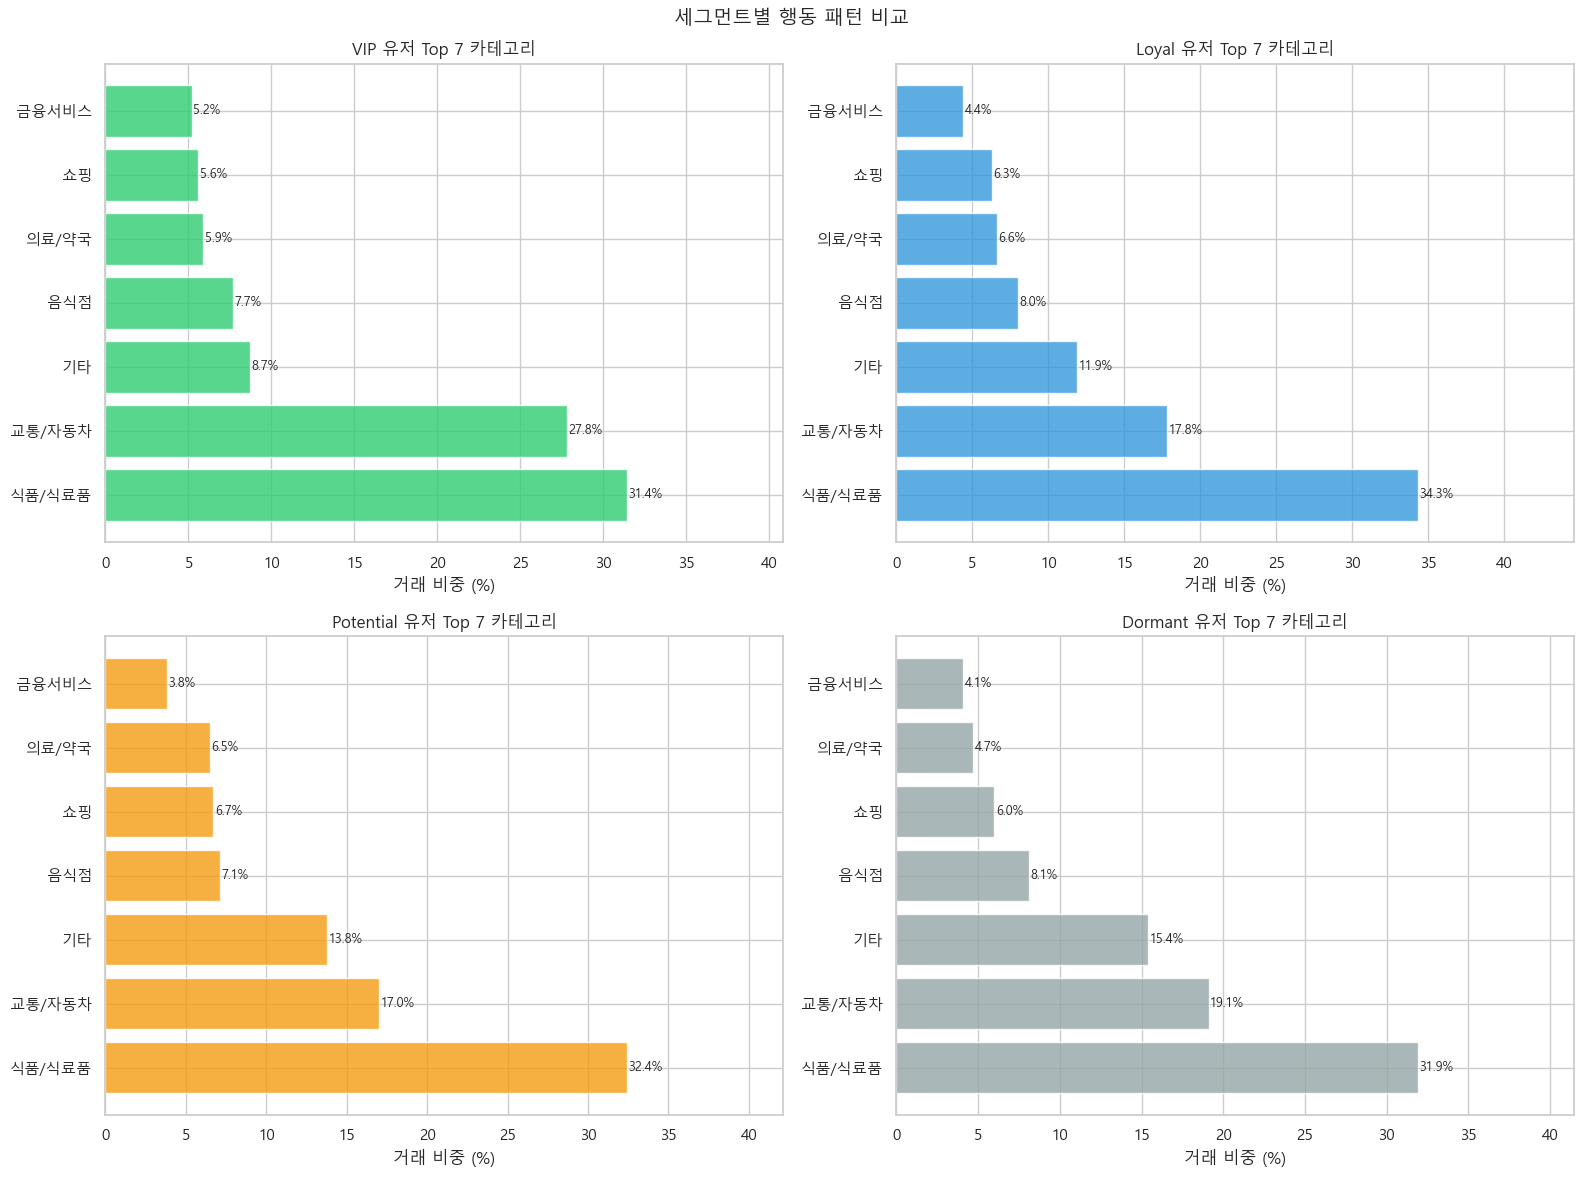

In [67]:
# Cell 18 - 세그먼트별 행동 시각화

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('세그먼트별 행동 패턴 비교', fontsize=14)

segments_to_compare = ['VIP', 'Loyal', 'Potential', 'Dormant']
colors_map = {'VIP': '#2ecc71', 'Loyal': '#3498db',
              'Potential': '#f39c12', 'Dormant': '#95a5a6'}

for ax, seg in zip(axes.flatten(), segments_to_compare):
    if seg not in seg_category['segment'].values:
        continue
    data = seg_category[seg_category['segment'] == seg].nlargest(7, 'ratio')
    bars = ax.barh(data['category'], data['ratio'],
                   color=colors_map[seg], alpha=0.8)
    for bar, val in zip(bars, data['ratio']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9)
    ax.set_title(f'{seg} 유저 Top 7 카테고리')
    ax.set_xlabel('거래 비중 (%)')
    ax.set_xlim(0, data['ratio'].max() * 1.3)

plt.tight_layout()
plt.savefig(r'..\outputs\rfm_segment_behavior.png', dpi=150)
plt.show()

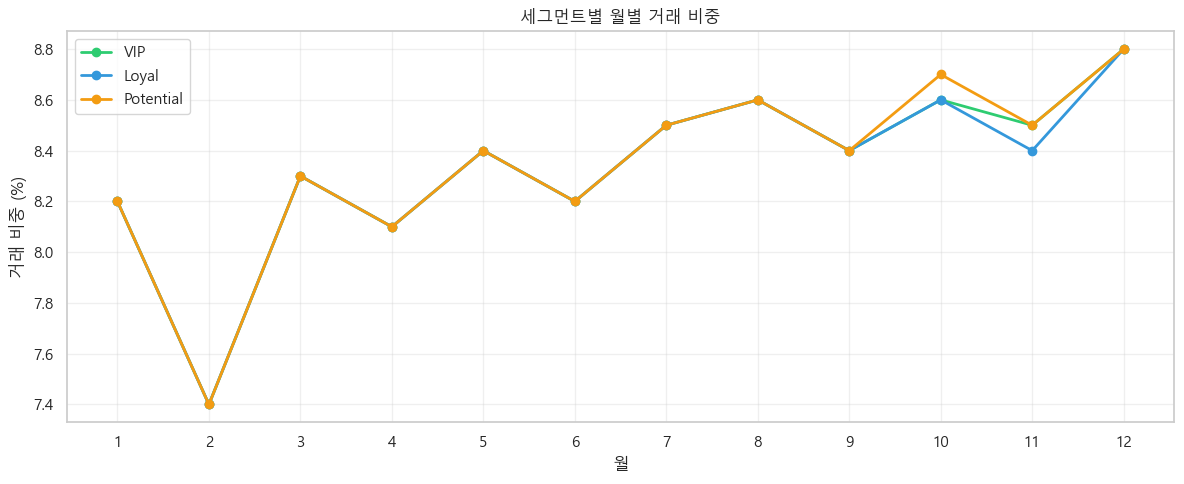

In [69]:
# Cell 19 - 세그먼트별 월별 거래 패턴 (계절성)

monthly_pattern = behavior_df.groupby(['segment', 'Month']).agg(
    avg_tx=('Amount', 'count')
).reset_index()

# 세그먼트별 정규화
monthly_total = monthly_pattern.groupby('segment')['avg_tx'].sum().reset_index()
monthly_total.columns = ['segment', 'total']
monthly_pattern = monthly_pattern.merge(monthly_total, on='segment')
monthly_pattern['ratio'] = (monthly_pattern['avg_tx'] /
                             monthly_pattern['total'] * 100).round(1)

plt.figure(figsize=(12, 5))
for seg, color in [('VIP', '#2ecc71'), ('Loyal', '#3498db'),
                   ('Potential', '#f39c12')]:
    data = monthly_pattern[monthly_pattern['segment'] == seg]
    plt.plot(data['Month'], data['ratio'],
             marker='o', label=seg, color=color, linewidth=2)

plt.title('세그먼트별 월별 거래 비중')
plt.xlabel('월')
plt.ylabel('거래 비중 (%)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'..\outputs\rfm_monthly_pattern.png', dpi=150)
plt.show()

*결과분석*

**카테고리 비중 분석**

- VIP와 Potential의 가장 큰 차이가 교통/자동차임. VIP 27.8% vs Potential 17.0%로 10%p 차이남.

- VIP 유저는 교통/자동차 관련 지출이 압도적으로 높음.

- 반면 식품/식료품은 VIP 31.4% vs Potential 32.4%로 거의 차이 없음. 모든 세그먼트가 비슷하게 쓰는 필수 지출임

**월별 패턴**

- 세 세그먼트가 거의 동일한 패턴임

- 2월에 모두 최저, 12월에 최고 

- 계절성이 세그먼트 구분 없이 동일하게 나타남

In [73]:
# Cell 20 - 세그먼트 분석 최종 인사이트 정리

print("=" * 55)
print("RFM 세그먼트 분석 최종 인사이트")
print("=" * 55)
print("""
[세그먼트 구성]
- VIP      421명 (31.5%): 연간 $86,667
- Loyal    449명 (33.6%): 연간 $46,426
- Potential 434명 (32.5%): 연간 $25,514
- At Risk    2명  (0.1%): 연간 $43,621
- Dormant   31명  (2.3%): 연간 $15,816

[VIP vs Potential 핵심 차이]
- 교통/자동차: VIP 27.8% vs Potential 17.0% (+10.8%p)
  → VIP는 자동차 관련 지출(주유, 자동차 수리 등)이 많음
- 식품/식료품: VIP 31.4% vs Potential 32.4% (차이 없음)
  → 필수 지출은 세그먼트 무관하게 동일

[월별 패턴]
- 전 세그먼트 공통: 2월 최저, 12월 최고
- 세그먼트 간 계절성 패턴 차이 없음

[A/B 테스트 가설 방향]
- Potential 유저(434명)의 교통/자동차 지출을 늘리면
  VIP로 전환 가능성 있음
- AARRR에서 Activation 34% 미전환 유저와 연결:
  초기 engagement 개선 → Potential → VIP 전환율 향상
""")

RFM 세그먼트 분석 최종 인사이트

[세그먼트 구성]
- VIP      421명 (31.5%): 연간 $86,667
- Loyal    449명 (33.6%): 연간 $46,426
- Potential 434명 (32.5%): 연간 $25,514
- At Risk    2명  (0.1%): 연간 $43,621
- Dormant   31명  (2.3%): 연간 $15,816

[VIP vs Potential 핵심 차이]
- 교통/자동차: VIP 27.8% vs Potential 17.0% (+10.8%p)
  → VIP는 자동차 관련 지출(주유, 자동차 수리 등)이 많음
- 식품/식료품: VIP 31.4% vs Potential 32.4% (차이 없음)
  → 필수 지출은 세그먼트 무관하게 동일

[월별 패턴]
- 전 세그먼트 공통: 2월 최저, 12월 최고
- 세그먼트 간 계절성 패턴 차이 없음

[A/B 테스트 가설 방향]
- Potential 유저(434명)의 교통/자동차 지출을 늘리면
  VIP로 전환 가능성 있음
- AARRR에서 Activation 34% 미전환 유저와 연결:
  초기 engagement 개선 → Potential → VIP 전환율 향상

